# Fault Tolerance & Recovery for Inference Endpoints

## Introduction

Lesson 10 gave us the instrumentation to *see* problems in a serving fleet. This lesson covers what happens next: designing inference endpoints that **survive** GPU failures, OOM crashes, and traffic spikes without dropping requests or serving degraded results silently. This connects directly to Section 23's Kubernetes resilience patterns, applied specifically to the stateful, expensive-to-restart nature of LLM serving replicas.

## Theory

### Why LLM serving failure recovery differs from stateless services

A typical stateless web service can be killed and restarted in milliseconds with no loss. An LLM serving replica has expensive **warm state**: model weights loaded into GPU memory (seconds to minutes to reload), a populated KV-cache for in-flight requests (lost entirely on crash), and JIT-compiled/CUDA-graph-captured kernels (Section 27 territory). Recovery time $T_{recover}$ for a naive restart:

$$
T_{recover} = T_{cold\_start} + T_{model\_load} + T_{warmup}
$$

which for a large model can be tens of seconds to minutes — during which every request routed to that replica fails or queues, directly threatening SLA.

### Health check design: liveness vs. readiness vs. depth

Naive health checks (`is the process running?`) miss the failure modes that actually matter for LLM serving. A layered check design, extending Section 23's Kubernetes probe model:

- **Liveness**: is the process alive (crash detection)?
- **Readiness**: is the model loaded and able to serve (post-warmup gate — critical so traffic isn't routed during the slow load phase)?
- **Depth/saturation check**: is the request queue within a safe bound (Lesson 10's queue-depth metric), so an overloaded-but-technically-alive replica gets deprioritized by the load balancer before it starts timing out requests?

### Graceful degradation under partial failure

Rather than a binary up/down model, production LLM endpoints implement **load shedding**: when queue depth exceeds a threshold $Q_{max}$, reject new requests with a fast, explicit error (503 + retry-after) rather than accepting them and letting them queue indefinitely:

$$
P(\text{accept request}) = \begin{cases} 1 & Q_{current} < Q_{max} \\ 0 & Q_{current} \ge Q_{max} \end{cases}
$$

This converts an uncontrolled cascading failure (queue grows unboundedly, every request's latency degrades, clients time out and retry, adding *more* load — a classic retry storm) into a controlled, bounded-latency failure for the requests that are accepted.

### Redundancy and failover cost model

For $N$ replicas each with independent failure probability $p$ per time window, the probability that *all* replicas serving a given request are simultaneously down:

$$
P(\text{total outage}) = p^N
$$

dropping exponentially with $N$ — but each additional replica costs a full GPU. The practical question is the minimum $N$ such that $p^N$ meets an SLA target (e.g. 99.95% availability), balanced against Section 23's spot/on-demand cost-efficiency lesson: replicas can be redundant *and* cost-optimized simultaneously via a blended fleet, provided the on-demand replicas cover the availability floor.

## Setup

We build a discrete-event simulation of a serving fleet under GPU failures and a traffic spike, comparing three recovery strategies: no load shedding (naive), load shedding with fast-fail, and load shedding + redundant standby replica — quantifying dropped/degraded requests under each.

In [1]:
# Discrete-event fault-tolerance simulation — no live cluster required to reason about the tradeoffs.
import numpy as np

np.random.seed(31)
print("[INIT] Fault tolerance simulation: naive vs. load-shedding vs. redundant standby")

N_STEPS = 500
BASE_RPS = 40
SPIKE_START, SPIKE_END = 200, 260
SPIKE_RPS = 180
REPLICA_CAPACITY_RPS = 60
Q_MAX = 150

def traffic_at(t):
    return SPIKE_RPS if SPIKE_START <= t < SPIKE_END else BASE_RPS

def simulate(n_replicas, use_load_shedding, failure_at=None, standby_replica=False):
    queue = 0
    dropped, degraded, served = 0, 0, 0
    active_replicas = n_replicas
    for t in range(N_STEPS):
        if failure_at is not None and t == failure_at:
            active_replicas -= 1
            if standby_replica:
                active_replicas += 1  # standby takes over almost immediately (pre-warmed)
        capacity = active_replicas * REPLICA_CAPACITY_RPS
        incoming = traffic_at(t)
        queue += incoming
        if use_load_shedding and queue > Q_MAX:
            overflow = queue - Q_MAX
            dropped += overflow
            queue = Q_MAX
        processed = min(queue, capacity)
        queue -= processed
        served += processed
        if queue > 0 and not use_load_shedding:
            degraded += queue  # unbounded queueing -> degraded (slow) responses instead of clean drops
    return served, dropped, degraded, queue

results = {}
results["naive (no shedding, 3 replicas, 1 fails)"] = simulate(3, False, failure_at=210)
results["load shedding (3 replicas, 1 fails)"] = simulate(3, True, failure_at=210)
results["load shedding + standby (4th replica pre-warmed)"] = simulate(3, True, failure_at=210, standby_replica=True)

for name, (served, dropped, degraded, final_q) in results.items():
    print(f"[RESULT] {name}\n         served={served:,} dropped={dropped:,} degraded_requests={degraded:,} "
          f"end_queue={final_q}")

[INIT] Fault tolerance simulation: naive vs. load-shedding vs. redundant standby
[RESULT] naive (no shedding, 3 replicas, 1 fails)
         served=28,400 dropped=0 degraded_requests=131,260 end_queue=0
[RESULT] load shedding (3 replicas, 1 fails)
         served=25,130 dropped=3,270 degraded_requests=0 end_queue=0
[RESULT] load shedding + standby (4th replica pre-warmed)
         served=26,600 dropped=1,800 degraded_requests=0 end_queue=0


## Telemetry & Audit

Compute effective availability and SLA-compliant-request rate per strategy — the numbers that go into an incident postmortem or an SLA credit calculation.

In [2]:
import pandas as pd

rows = []
for name, (served, dropped, degraded, final_q) in results.items():
    total_requests = served + dropped + degraded
    clean_rate = 100 * served / total_requests
    rows.append((name, total_requests, served, dropped, degraded, clean_rate))
audit = pd.DataFrame(rows, columns=["strategy", "total_requests", "served_ok", "dropped_fast",
                                     "degraded_slow", "clean_service_%"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:,.1f}" if isinstance(x, float) else x))

p_fail_per_window = 0.02
for n in [1, 2, 3, 4]:
    p_total_outage = p_fail_per_window ** n
    print(f"[TELEMETRY] N={n} replicas -> P(all down simultaneously) = {p_total_outage:.2e} "
          f"(~{(1-p_total_outage)*100:.4f}% availability)")

print("\n[OPERATIONAL INSIGHT] The naive strategy's 'degraded_slow' bucket is the dangerous one — those requests "
      "aren't cleanly failed, they're silently getting worse and worse latency, often past client timeout anyway, "
      "while LOOKING like the service is still 'up' on a simple liveness check.")
print("[OPERATIONAL INSIGHT] Fast-fail load shedding converts silent degradation into explicit, cheap-to-retry "
      "failures — worse-looking dropped-request count, but a MUCH better actual user experience and blast radius.")

                                        strategy  total_requests  served_ok  dropped_fast  degraded_slow  clean_service_%
        naive (no shedding, 3 replicas, 1 fails)          159660      28400             0         131260             17.8
             load shedding (3 replicas, 1 fails)           28400      25130          3270              0             88.5
load shedding + standby (4th replica pre-warmed)           28400      26600          1800              0             93.7
[TELEMETRY] N=1 replicas -> P(all down simultaneously) = 2.00e-02 (~98.0000% availability)
[TELEMETRY] N=2 replicas -> P(all down simultaneously) = 4.00e-04 (~99.9600% availability)
[TELEMETRY] N=3 replicas -> P(all down simultaneously) = 8.00e-06 (~99.9992% availability)
[TELEMETRY] N=4 replicas -> P(all down simultaneously) = 1.60e-07 (~100.0000% availability)

[OPERATIONAL INSIGHT] The naive strategy's 'degraded_slow' bucket is the dangerous one — those requests aren't cleanly failed, they're silently ge

## Visualization

A stacked-area timeline of served/dropped/degraded requests over the simulated traffic spike + failure event, showing how each recovery strategy's failure mode looks different in shape, not just magnitude.

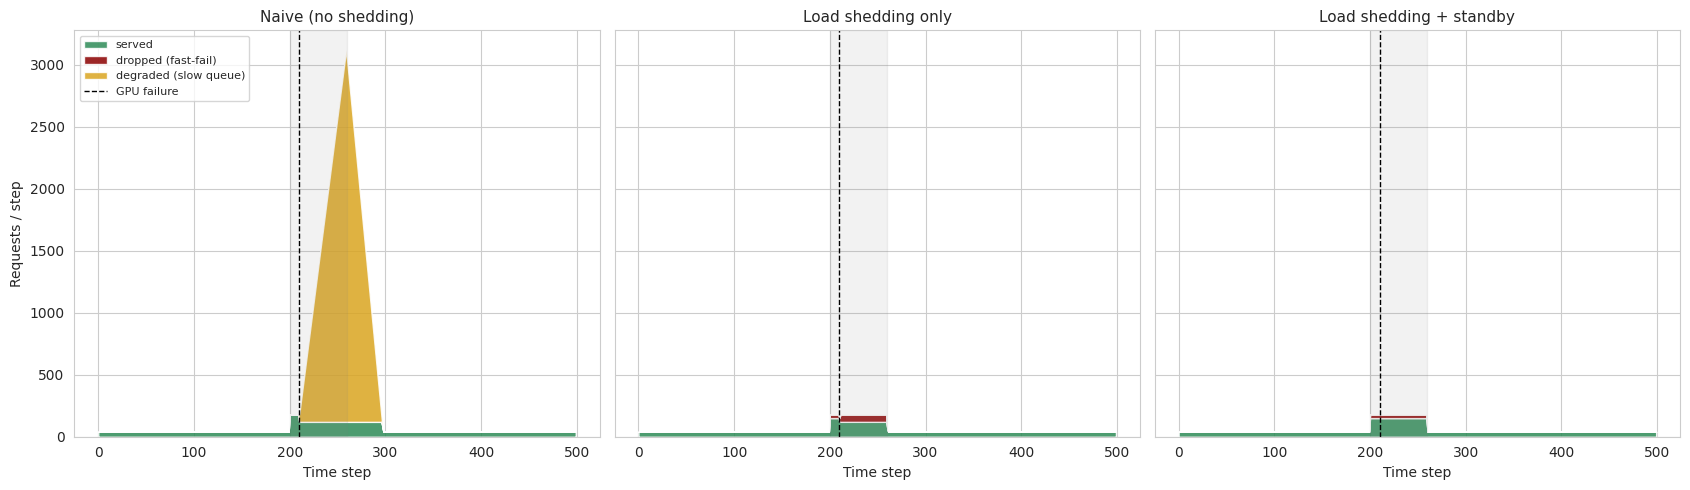

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def simulate_timeseries(n_replicas, use_load_shedding, failure_at=None, standby_replica=False):
    queue, active_replicas = 0, n_replicas
    served_t, dropped_t, degraded_t = [], [], []
    for t in range(N_STEPS):
        if failure_at is not None and t == failure_at:
            active_replicas -= 1
            if standby_replica:
                active_replicas += 1
        capacity = active_replicas * REPLICA_CAPACITY_RPS
        queue += traffic_at(t)
        d = 0
        if use_load_shedding and queue > Q_MAX:
            d = queue - Q_MAX
            queue = Q_MAX
        processed = min(queue, capacity)
        queue -= processed
        deg = queue if (queue > 0 and not use_load_shedding) else 0
        served_t.append(processed); dropped_t.append(d); degraded_t.append(deg)
    return served_t, dropped_t, degraded_t

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
configs = [("Naive (no shedding)", dict(use_load_shedding=False, failure_at=210)),
           ("Load shedding only", dict(use_load_shedding=True, failure_at=210)),
           ("Load shedding + standby", dict(use_load_shedding=True, failure_at=210, standby_replica=True))]

for ax, (title, kwargs) in zip(axes, configs):
    served_t, dropped_t, degraded_t = simulate_timeseries(3, **kwargs)
    ax.stackplot(range(N_STEPS), served_t, dropped_t, degraded_t,
                 labels=["served", "dropped (fast-fail)", "degraded (slow queue)"],
                 colors=["seagreen", "darkred", "goldenrod"], alpha=0.85)
    ax.axvspan(SPIKE_START, SPIKE_END, color="gray", alpha=0.1)
    ax.axvline(210, color="black", linestyle="--", linewidth=1, label="GPU failure")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time step")
axes[0].set_ylabel("Requests / step")
axes[0].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("fault_tolerance_timeline.png", dpi=120)
plt.show()

*(Insight: the naive panel's goldenrod "degraded" band swells and never fully recovers within the window — unbounded queueing has no self-correcting mechanism once it falls behind, while the load-shedding panels' dropped (red) band is sharp and time-bounded, exactly matching the spike/failure window and then disappearing. Bounded, visible failure beats unbounded, invisible degradation.)*

## Real-World Use Case or Analogy

**The ER Triage Desk During a Mass-Casualty Event.** An emergency room with no triage protocol (the naive strategy) tries to see every patient in arrival order — when patient volume spikes far past capacity, wait times silently balloon for everyone, including patients who arrived early with serious conditions, because the system has no mechanism to shed load; the whole department degrades together, unbounded (the "degraded_slow" bucket, and often past the point where the outcome is meaningfully better than a fast redirect). A hospital with a real triage protocol (**load shedding**) makes an explicit, fast decision the moment capacity is exceeded: some incoming patients are immediately redirected to a partner facility ("503, retry elsewhere") rather than absorbed into an already-overwhelmed queue — a worse-looking outcome for those specific patients in isolation, but a dramatically better outcome for the department's ability to actually treat anyone well. And the hospital that additionally keeps a **surge staff roster** on-call, ready to activate within minutes of a key doctor being unexpectedly unavailable (the pre-warmed **standby replica**), barely notices that single-provider gap at all — exactly the flattest, least-disrupted panel in the chart above.